In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✓ Libraries loaded!')

✓ Libraries loaded!


In [3]:
#load dataset
iris = load_iris()
x = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,
                                                    random_state=42)
print(f'Dataset: {len(x)} samples, {len(feature_names)} features')
print(f'Classes: {class_names}')

Dataset: 150 samples, 4 features
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [5]:
train_acc = tree.score(x_train, y_train)
test_acc = tree.score(x_test, y_test)
print(f'Train Accuracy: {train_acc:.3f}')
print(f'Test Accuracy: {test_acc:.3f}')
print(f'Tree Depth: {tree.get_depth()}')
print(f'Number of leaves: {tree.get_n_leaves()}')

Train Accuracy: 0.952
Test Accuracy: 1.000
Tree Depth: 3
Number of leaves: 5


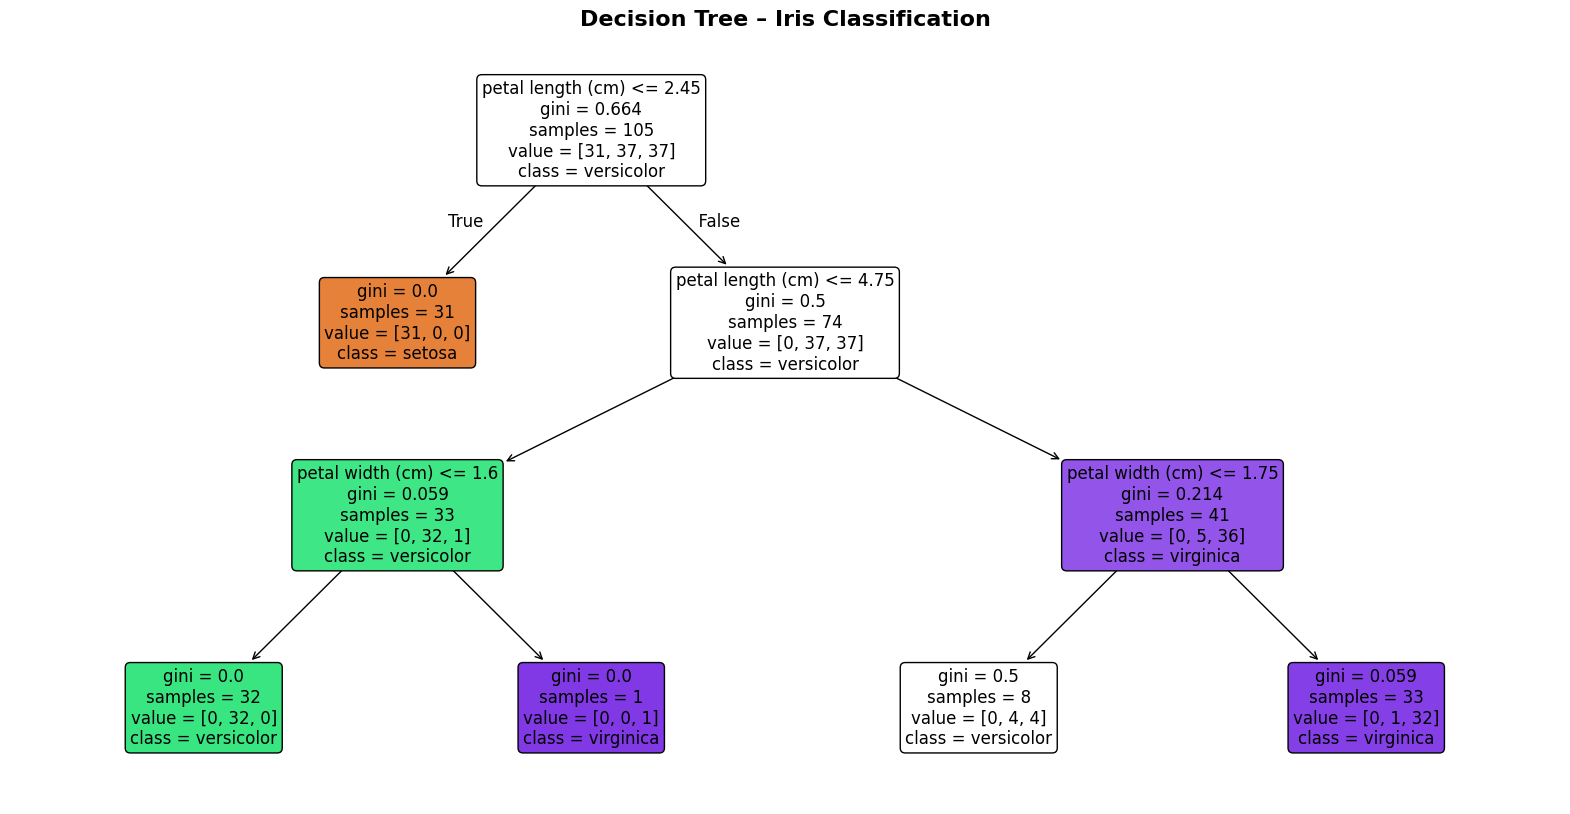

Node interpretation:
• Color: Majority class (darker = more pure)
• Gini: Impurity (0 = pure, 0.5 = mixed)
• samples: Training samples in node
• value: [class_0, class_1, class_2] counts


In [6]:
plt.figure(figsize=(20, 10))

plot_tree(tree,
          filled=True,
          feature_names=feature_names,
          class_names=list(class_names),
          rounded=True,
          fontsize=12)
plt.title('Decision Tree – Iris Classification', fontsize=16, fontweight='bold')
plt.show()
print('Node interpretation:')
print('• Color: Majority class (darker = more pure)')
print('• Gini: Impurity (0 = pure, 0.5 = mixed)')
print('• samples: Training samples in node')
print('• value: [class_0, class_1, class_2] counts')